<a href="https://colab.research.google.com/github/Schlomo-khalidi/PytorchML/blob/main/DataSets%20%26%20DataLoaders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Downloading Test and Train Data**

In [2]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import v2
import matplotlib.pyplot as plt

training_data = datasets.FashionMNIST(
    root = "data",
    train= True,
    download=True,
    transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])

)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)



100%|██████████| 26.4M/26.4M [00:01<00:00, 13.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 210kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.90MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.7MB/s]


# **Iterating and Visualizing the dataset**

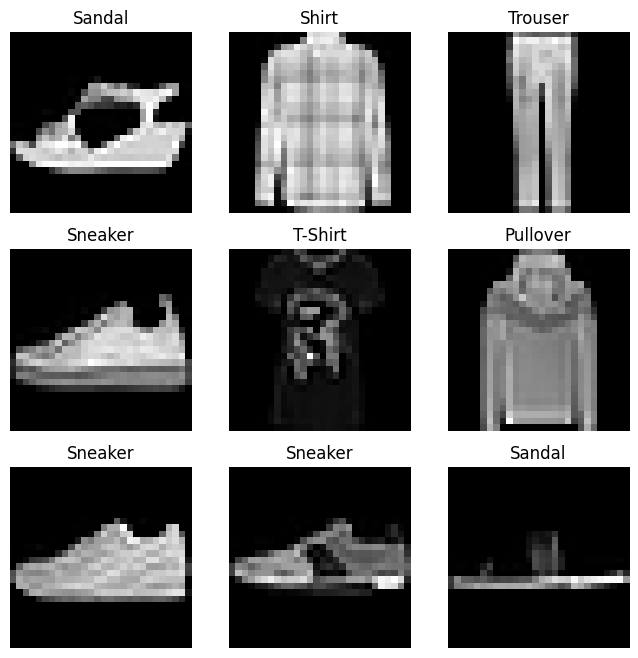

In [3]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

# **Creating a Custom DataSet for my files**

In [7]:
import os
import pandas as pd
from torchvision.io import decode_image

class CustomImageDataset(Dataset):
  def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
    self.img_labels = pd.read_csv(annotations_file)
    self.img_dir = img_dir
    self.transform = transform
    self.target_transform = target_transform

  def __len__(self):
    return len(self.img_labels)

  def __getitem__(self, idx):
    #identifing the image location on the disk  based on the index
    image_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
    #converting the image to a tensor
    image = decode_image(open(image_path, "rb").read())
    #retriving the coresponding label from the csv data
    label = self.img_labels.iloc[idx, 1]
    #calling the transform functions (if necessary)
    if self.transform:
      image = self.transform(image)
    if self.target_transform:
      label = self.target_transform(label)
    #returning the tensor image and the coresponding label in a tuple
    return image, label

# **Preparing the data for Training with DataLoader**

In [9]:
from torch.utils.data import DataLoader
train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_data = DataLoader(test_data, batch_size=64, shuffle=True)

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


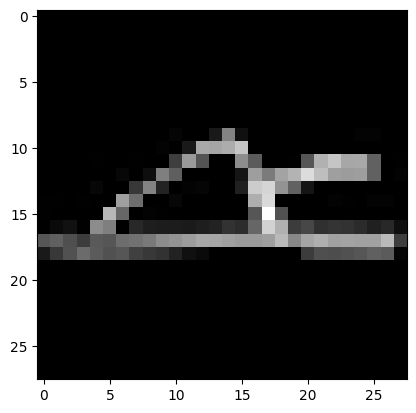

Label: 5


In [10]:
#Iterating through the data Loader
#Display image and label
train_features, train_labels = next(iter(train_dataloader))
print(f"feature batch shape: {train_features.size()}")
print(f"labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"label: {label}")